**Problem 3**

Consider the Anemia Levels in Nigeria dataset:
(Kaggle Dataset - Factors Affecting Children Anemia Level
), which can be downloaded from Kaggle. The dataset comes from the 2018 Nigeria Demographic and Health Surveys (NDHS). It explores the impact of mothers' age and socioeconomic factors on anemia levels among children aged 0–59 months across Nigeria’s 36 states and the Federal Capital Territory. Based on the above data, create a contingency table, apply chi-square test, formulate hypothesis, create a contribution diagram, and interpret the findings.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

In [2]:
#load dataset

df = pd.read_csv("/content/children anemia.csv")

In [3]:
df.columns

Index(['Age in 5-year groups', 'Type of place of residence',
       'Highest educational level', 'Wealth index combined',
       'Births in last five years', 'Age of respondent at 1st birth',
       'Hemoglobin level adjusted for altitude and smoking (g/dl - 1 decimal)',
       'Anemia level',
       'Have mosquito bed net for sleeping (from household questionnaire)',
       'Smokes cigarettes', 'Current marital status',
       'Currently residing with husband/partner', 'When child put to breast',
       'Had fever in last two weeks',
       'Hemoglobin level adjusted for altitude (g/dl - 1 decimal)',
       'Anemia level.1', 'Taking iron pills, sprinkles or syrup'],
      dtype='object')

In [4]:
#Select Required Variables
data = df[[
    'Highest educational level',
    'Anemia level'
]]

In [5]:
#Remove Missing Values
data = data.dropna()

In [6]:
data.shape

(13136, 2)

In [7]:
#View Unique Categories
print(data['Highest educational level'].unique())

print(data['Anemia level'].unique())

['Secondary' 'Higher' 'No education' 'Primary']
['Moderate' 'Mild' 'Not anemic' 'Severe']


In [8]:
#Create Contingency Table
table = pd.crosstab(
    data['Highest educational level'],
    data['Anemia level']
)

print(table)

Anemia level               Mild  Moderate  Not anemic  Severe
Highest educational level                                    
Higher                      296       238         591      14
No education               1450      1769        1874     113
Primary                     608       645         900      42
Secondary                  1240      1322        1972      62


In [9]:
#Percentage Table


row_percent = pd.crosstab(
    data['Highest educational level'],
    data['Anemia level'],
    normalize='index'
) * 100

print(row_percent.round(2))

Anemia level                Mild  Moderate  Not anemic  Severe
Highest educational level                                     
Higher                     25.99     20.90       51.89    1.23
No education               27.85     33.98       36.00    2.17
Primary                    27.70     29.38       41.00    1.91
Secondary                  26.98     28.76       42.91    1.35


Hypotheses
**Null Hypothesis**
H0
	​ :Educational level and anemia level are independent


**Alternative Hypothesis**
H1 :Educational level and anemia level are associated



In [10]:
#Chi-Square Test
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)

Chi-square Statistic: 142.86240492075743
Degrees of Freedom: 9
P-value: 2.644147441640121e-26


**Interpretation of Chi-Square Test**

The chi-square test results indicate a statistically significant association between educational level and anemia level.

Chi-square statistic = 142.86
Degrees of freedom = 9
p-value = 2.64 × 10⁻²⁶

Since:

p<0.05

we reject the null hypothesis of independence.

This suggests that anemia levels vary significantly across different educational levels, indicating that educational status may be an important factor related to child anemia outcomes.

In [11]:
#Chi-Square Contribution Matrix
contribution = ((table - expected)**2) / expected

print(contribution.round(2))

Anemia level               Mild  Moderate  Not anemic  Severe
Highest educational level                                    
Higher                     0.78     32.96       35.54    1.82
No education               0.46     23.91       27.49    5.03
Primary                    0.09      0.55        0.08    0.30
Secondary                  0.24      3.37        5.87    4.38


**Interpretation of Contribution Matrix**

The contribution matrix shows which combinations of educational level and anemia level contribute most to the chi-square statistic.

The largest contributions are observed for:

Higher education × Not anemic (35.54)
Higher education × Moderate anemia (32.96)
No education × Not anemic (27.49)
No education × Moderate anemia (23.91)

These large values indicate that these categories are mainly responsible for the significant association between educational level and anemia status.

The results suggest that children’s anemia outcomes differ considerably across maternal educational groups, especially between higher education and no education categories.

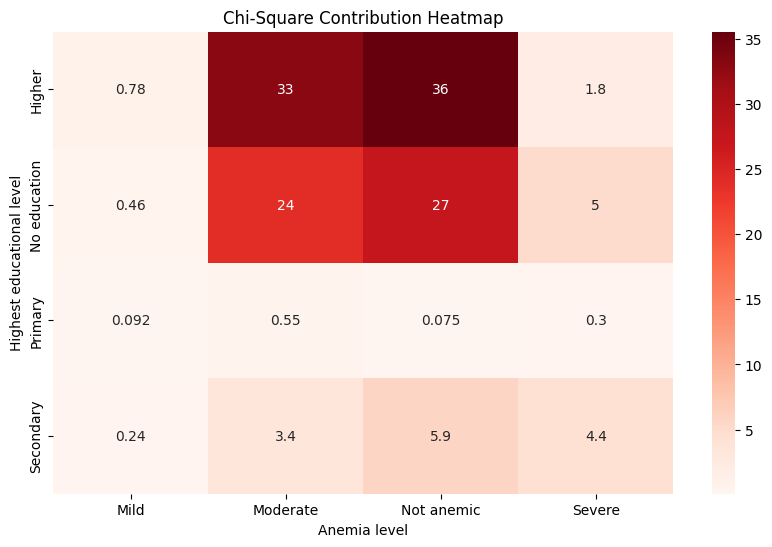

In [12]:
#Contribution Heatmap/diagram
plt.figure(figsize=(10,6))

sns.heatmap(
    contribution,
    annot=True,
    cmap='Reds'
)

plt.title("Chi-Square Contribution Heatmap")

plt.show()

Interpretation of Heatmap

The heatmap visualizes the contribution of each cell to the overall chi-square statistic.

Darker red cells indicate higher contributions and stronger deviations from expected frequencies.
The cells for:
Higher education × Not anemic
Higher education × Moderate anemia
No education × Not anemic
No education × Moderate anemia

show the largest contributions.

This means these categories are the main drivers of the significant association between educational level and anemia status.

In contrast, the Primary education group shows very small contribution values, indicating little influence on the chi-square result.